
# Lab_5: FEM 1D

### Exercise 1: solve the EDO

Use FEM to solve the next EDO (use the code seen in class). Compare with the analytical solution for some N elements.

\begin{equation}
\dfrac{d^2y}{dx^2}=-xe^x\,,\text{with}\; y(0)=(3-e)  \;, y(1)=0
\end{equation}


* Build a general scrip to solve a PDE of order two with Dirichlet's conditions: $y(a), y(b), x\,\epsilon\, [a,b]$. Use the method seen in class.

Nota: Solving the Green's function for this particular case we are able to find the analytical solution:
\begin{equation}
y(x) = 1-e-e^x(2-x)-x
\end{equation}

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import quad
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import spsolve

# Método de uso
# A_sparse = csr_matrix(A)
# x = spsolve(A_sparse, b)



Para la solución del ejercicio quise implementar una clase llamada PoissonSolver, esto con el objetivo de practicar POO. Note que la clase posee dos metodos principales .solve y .get_solution_funtion, estos me permiten 1) calcular los coeficientes de la expansión de Garlekin y 2) obtener la serie de Garlekin lista para evaluar la función

In [ ]:
import numpy as np
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from scipy.integrate import quad

class PoissonSolver:
    """
    Solver optimizado para la PDE de Poisson 1D (-u'' = F) usando FEM con elementos lineales.
    """
    def __init__(self, F, domain: np.ndarray, Y_bound: np.ndarray, N_points: int = 15):
        self.F = F
        self.domain = domain
        self.Y_bound = Y_bound
        self.N_points = N_points
        self.points = np.linspace(self.domain[0], self.domain[1], self.N_points)
        self.h = np.diff(self.points)

    def assemble_system(self):
        n_internal = self.N_points - 2
        
        # Matriz A - Se crea a partir de los calculos analiticos (ver notebook del profe)
        main_diag = 1.0 / self.h[:-1] + 1.0 / self.h[1:]
        off_diag = -1.0 / self.h[1:-1]
        
        # Crear la matriz dispersa tridiagonal directamente
        self.A = diags([off_diag, main_diag, off_diag], offsets=[-1, 0, 1], format='csr')

        # Vector de b
        self.b = np.zeros(n_internal)
        for i in range(1, self.N_points - 1):
            x_left = self.points[i-1]
            x_mid = self.points[i]
            x_right = self.points[i+1]

            # Solo integramos donde la función base no es cero
            integrand_left = lambda x: self.F(x) * (x - x_left) / (x_mid - x_left)
            integrand_right = lambda x: self.F(x) * (x_right - x) / (x_right - x_mid)

            int_left, _ = quad(integrand_left, x_left, x_mid)
            int_right, _ = quad(integrand_right, x_mid, x_right)
            
            self.b[i-1] = int_left + int_right

        # Condiciones de frontera Dirichlet
        # Modificamos el primer y último elemento del vector b para imponer los bordes
        # Note que la integral da cero para todos los elementos excepto el primero y el último, 
        # donde la función base es no nula en el borde.

        self.b[0] -= self.Y_bound[0] * (-1.0 / self.h[0])
        self.b[-1] -= self.Y_bound[1] * (-1.0 / self.h[-1])

    def solve(self):
        self.assemble_system()
        
        # Resolver el sistema para los nodos internos
        u_internal = spsolve(self.A, self.b)
        
        # Concatenar las fronteras para obtener el vector solución completo
        self.u_discrete = np.concatenate(([self.Y_bound[0]], u_internal, [self.Y_bound[1]]))
        return self.u_discrete

    def get_solution_function(self):
        """
        Retorna una función continua u(x) que evalúa la solución en cualquier punto del dominio.
        """
        if not hasattr(self, 'u_discrete'):
            self.solve()
                        
        def u(x):
            return np.interp(x, self.points, self.u_discrete)
            
        return u

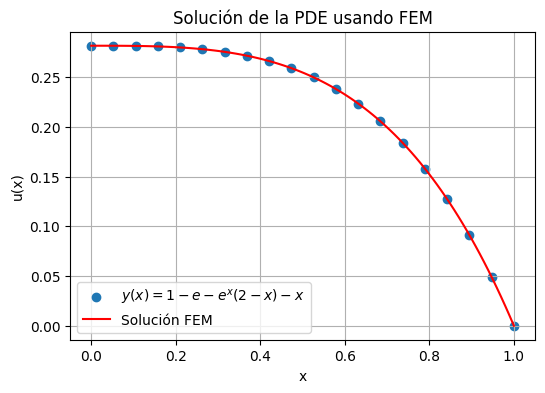

In [24]:
Function1 = lambda x: x * np.exp(x)
Dominio1 = np.array([0, 1])
Boundary1 = np.array([3-np.e, 0])
N1 = 1000

solver1 = PoissonSolver(Function1, Dominio1, Boundary1, N1)
u1 = solver1.get_solution_function()


x_values = np.linspace(Dominio1[0], Dominio1[1], 100)
u_values = np.array([u1(x) for x in x_values])
def y(x):
    return 1 - np.e + np.exp(x)*(2 - x) - x

x = np.linspace(0, 1, 20)
y_vals = y(x)

plt.figure(figsize=(6, 4))
plt.scatter(x, y_vals, label=r"$y(x)=1-e-e^x(2-x)-x$")
plt.plot(x_values, u_values, label='Solución FEM', c="red")
plt.title('Solución de la PDE usando FEM')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.legend()
plt.grid()
plt.show()



### Exercise 2: Solve the EDO:  

see pag 36: https://cimec.org.ar/foswiki/pub/Main/Cimec/CursoFEM/cursofem_1.pdf

$-\dfrac{d^2U}{dx^2}(x)=\sin(\pi x)\,,$
in $0\le x\le 1$, with $U(0)=U(1)=0$.

The exact solution is known $U(x)=\dfrac{1}{\pi^2}\sin(\pi x)$.

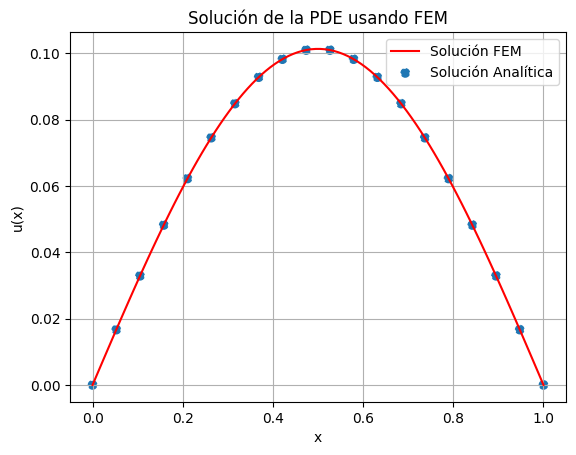

In [26]:
Function2 = lambda x: np.sin(np.pi * x)
Dominio2 = np.array([0, 1])
Boundary2 = np.array([0, 0])
N2 = 1000

solver2 = PoissonSolver(Function2, Dominio2, Boundary2, N2)
u2 = solver2.get_solution_function()


x_values = np.linspace(Dominio2[0], Dominio2[1], 100)
u_values = np.array([u2(x) for x in x_values])

y_values = np.sin(np.pi * x) / (np.pi**2)

plt.plot(x_values, u_values, label='Solución FEM', c="red")
plt.scatter(x, y_values, label='Solución Analítica', linestyle='dashed')
plt.title('Solución de la PDE usando FEM')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.legend()
plt.grid()
plt.show()